In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

In [46]:
data=pd.read_csv("/content/train.csv")

In [47]:
data.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [48]:
data.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,259
LotArea,0
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


In [49]:
data

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [50]:
y = data["SalePrice"]
X = data.drop("SalePrice", axis=1)

In [52]:
X = X.select_dtypes(include=["int64", "float64"])

In [53]:
X = X.fillna(X.median())

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


In [55]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [56]:
models = {
    "Linear Regression (No Regularization)": LinearRegression(),
    "Lasso Regression (L1)": Lasso(alpha=0.01),
    "Ridge Regression (L2)": Ridge(alpha=1.0),
    "Elastic Net Regression": ElasticNet(alpha=0.01, l1_ratio=0.5)
}

In [57]:
results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)

    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    results.append([name, train_mse, test_mse, train_r2, test_r2])

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.257e+09, tolerance: 6.967e+08
  model = cd_fast.enet_coordinate_descent(


In [58]:
performance_df = pd.DataFrame(
    results,
    columns=["Model", "Train MSE", "Test MSE", "Train R2", "Test R2"]
)

print("\n===== MODEL PERFORMANCE (BEFORE & AFTER REGULARIZATION) =====\n")
print(performance_df)



===== MODEL PERFORMANCE (BEFORE & AFTER REGULARIZATION) =====

                                   Model     Train MSE      Test MSE  \
0  Linear Regression (No Regularization)  1.149707e+09  1.360121e+09   
1                  Lasso Regression (L1)  1.149707e+09  1.360121e+09   
2                  Ridge Regression (L2)  1.149709e+09  1.360053e+09   
3                 Elastic Net Regression  1.149779e+09  1.359806e+09   

   Train R2   Test R2  
0  0.807243  0.822678  
1  0.807243  0.822678  
2  0.807243  0.822686  
3  0.807231  0.822719  


In [59]:
lasso = models["Lasso Regression (L1)"]
ridge = models["Ridge Regression (L2)"]
elastic = models["Elastic Net Regression"]

print("\n===== COEFFICIENT ANALYSIS =====")
print("Total Features:", X.shape[1])
print("Lasso Non-Zero Coefficients:", np.sum(lasso.coef_ != 0))
print("Ridge Non-Zero Coefficients:", np.sum(ridge.coef_ != 0))
print("Elastic Net Non-Zero Coefficients:", np.sum(elastic.coef_ != 0))


===== COEFFICIENT ANALYSIS =====
Total Features: 37
Lasso Non-Zero Coefficients: 37
Ridge Non-Zero Coefficients: 37
Elastic Net Non-Zero Coefficients: 37


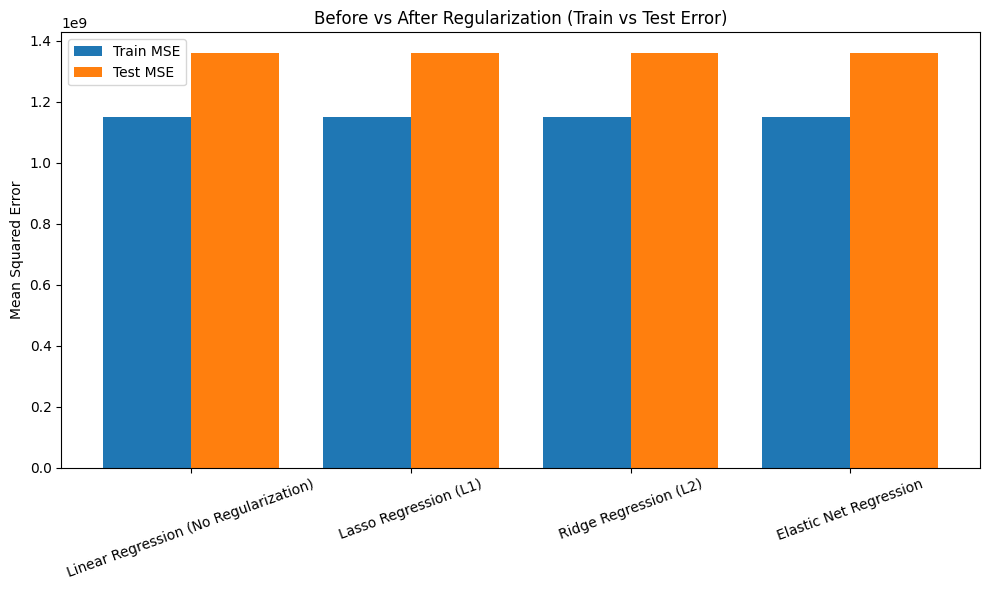

In [60]:
plt.figure(figsize=(10, 6))

x = np.arange(len(performance_df))
plt.bar(x - 0.2, performance_df["Train MSE"], width=0.4, label="Train MSE")
plt.bar(x + 0.2, performance_df["Test MSE"], width=0.4, label="Test MSE")

plt.xticks(x, performance_df["Model"], rotation=20)
plt.ylabel("Mean Squared Error")
plt.title("Before vs After Regularization (Train vs Test Error)")
plt.legend()
plt.tight_layout()
plt.show()

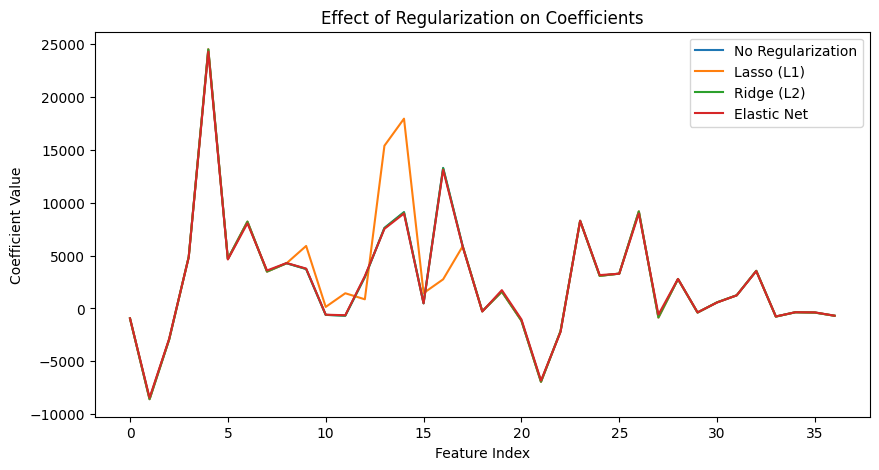

In [61]:
plt.figure(figsize=(10, 5))

plt.plot(models["Linear Regression (No Regularization)"].coef_, label="No Regularization")
plt.plot(lasso.coef_, label="Lasso (L1)")
plt.plot(ridge.coef_, label="Ridge (L2)")
plt.plot(elastic.coef_, label="Elastic Net")

plt.legend()
plt.title("Effect of Regularization on Coefficients")
plt.xlabel("Feature Index")
plt.ylabel("Coefficient Value")
plt.show()

In [62]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso (alpha=1.0)": Lasso(alpha=1.0),
    "Ridge (alpha=50)": Ridge(alpha=50),
    "Elastic Net (alpha=1.0)": ElasticNet(alpha=1.0, l1_ratio=0.5)
}


In [63]:
results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)

    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    results.append([name, train_mse, test_mse, train_r2, test_r2])

In [64]:
performance_df = pd.DataFrame(
    results,
    columns=["Model", "Train MSE", "Test MSE", "Train R2", "Test R2"]
)

print("\n===== MODEL PERFORMANCE (BEFORE & AFTER REGULARIZATION) =====\n")
print(performance_df)


===== MODEL PERFORMANCE (BEFORE & AFTER REGULARIZATION) =====

                     Model     Train MSE      Test MSE  Train R2   Test R2
0        Linear Regression  1.149707e+09  1.360121e+09  0.807243  0.822678
1        Lasso (alpha=1.0)  1.149707e+09  1.360115e+09  0.807243  0.822678
2         Ridge (alpha=50)  1.153535e+09  1.361919e+09  0.806601  0.822443
3  Elastic Net (alpha=1.0)  1.258518e+09  1.498812e+09  0.789000  0.804596


In [65]:
from sklearn.datasets import load_diabetes

In [66]:
X, y = load_diabetes(return_X_y=True)


In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)


In [68]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [69]:

models = {
    "Linear Regression": LinearRegression(),
    "Lasso (alpha=1.0)": Lasso(alpha=1.0),
    "Ridge (alpha=10)": Ridge(alpha=10),
    "Elastic Net (alpha=1.0)": ElasticNet(alpha=1.0, l1_ratio=0.5)
}


In [70]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    results.append([
        name,
        mean_squared_error(y_train, train_pred),
        mean_squared_error(y_test, test_pred),
        r2_score(y_train, train_pred),
        r2_score(y_test, test_pred)
    ])

In [71]:
df = pd.DataFrame(
    results,
    columns=["Model", "Train MSE", "Test MSE", "Train R2", "Test R2"]
)

print("\n===== REGULARIZATION EFFECT (DIABETES DATASET) =====\n")
print(df)


===== REGULARIZATION EFFECT (DIABETES DATASET) =====

                     Model    Train MSE     Test MSE  Train R2   Test R2
0        Linear Regression  2907.257764  2848.310651  0.519034  0.484906
1        Lasso (alpha=1.0)  2939.689564  2784.984800  0.513669  0.496358
2         Ridge (alpha=10)  2926.181868  2830.691344  0.515903  0.488092
3  Elastic Net (alpha=1.0)  3118.855841  2856.779036  0.484028  0.483374


Regularization improves model generalization by increasing bias and reducing variance.
In the diabetes dataset, Lasso regression reduced test error compared to ordinary linear regression, demonstrating effective regularization.
Excessive regularization (Elastic Net) led to underfitting.

L1 and L2 regularization increase training error slightly but reduce test error by preventing overfitting.